In [ ]:
from pathlib import Path
import pandas as pd
from IPython.display import display
from lib import util

# Load data
df = util.load_data()
display(df.head())

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg


In [3]:
# Choosing Disziplin / Gender 

disziplin = "Hochsprung"
gender = "M"
altersklasse = "Maenner"
filtered_data = df[(df["disziplin"] == disziplin) & (df["geschlecht"] == gender) & (df["altersklasse"] == altersklasse)]
filtered_data.head()


,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort
5096,2005,M,Maenner,Hochsprung,2.3,NaN,Roman Fricke,1977,TSV Bayer Leverkusen,24.06.,Buehl
5097,2005,M,Maenner,Hochsprung,2.26,NaN,Eike Onnen,1982,LG Hannover,03.07.,Wattenscheid
5098,2005,M,Maenner,Hochsprung,2.25,NaN,Matthias Haverney,1985,SC Magdeburg,17.07.,Erfurt
5099,2005,M,Maenner,Hochsprung,2.22,NaN,Stefan Haefner,1984,MTG Mannheim,24.06.,Buehl
5100,2005,M,Maenner,Hochsprung,2.21,NaN,Martin Guenther,1986,TV Wehr,20.08.,Eberstadt


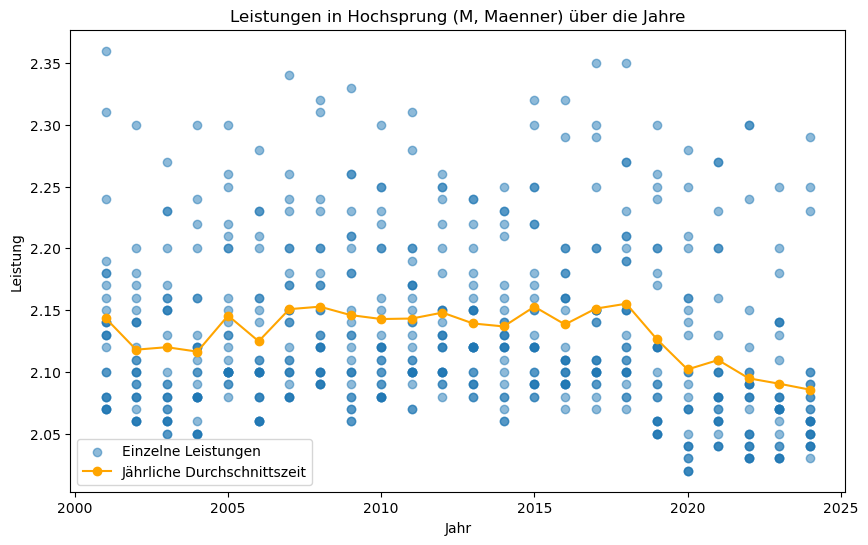

In [ ]:
import lib.plotting_style as plt
# Plot all data points with times on y-axis and year on x-axis + Mean per year line
# For each year, select top 25 athletes and compute mean
top25_per_year = (
    filtered_data.sort_values(["jahr", "leistung"], ascending=[True, False])  # sort by year and descending performance
                 .groupby("jahr")
                 .head(25)  # take top 25 per year
)

mean_per_year = top25_per_year.groupby("jahr")["leistung"].mean()
plt.figure(figsize=(10, 6))
plt.scatter(top25_per_year["jahr"], top25_per_year["leistung"], alpha=0.5, label="Einzelne Leistungen")
plt.plot(mean_per_year.index, mean_per_year.values, color='orange', marker='o', label='Jährliche Durchschnittszeit')
plt.title(f'Leistungen in {disziplin} ({gender}, {altersklasse}) über die Jahre')
plt.xlabel('Jahr')              
plt.ylabel('Leistung')
plt.legend()
plt.show()

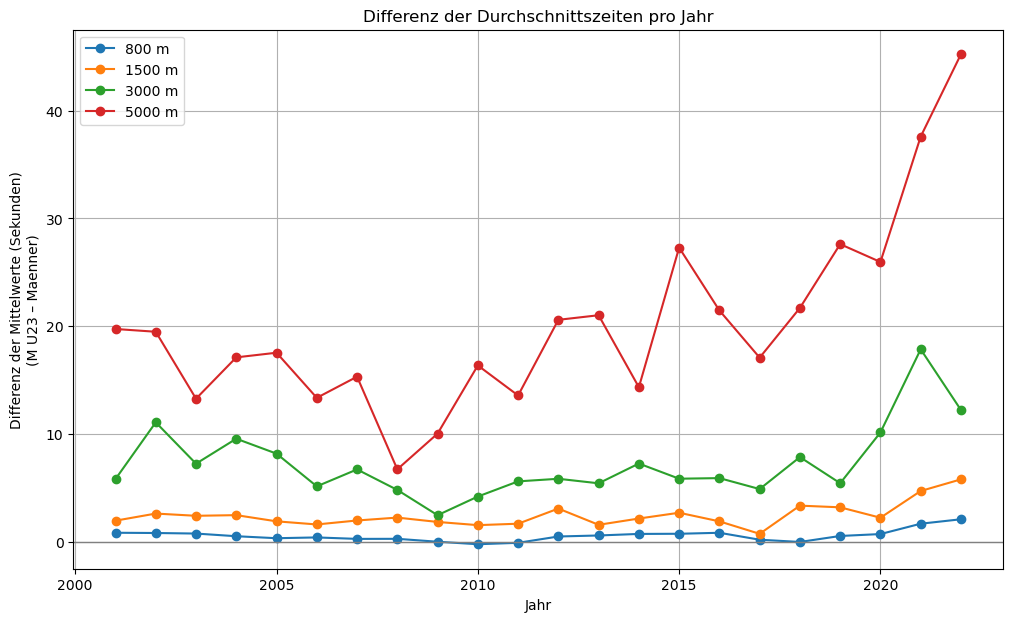

In [5]:
plt.figure(figsize=(12, 7))

disziplinen = ["800 m","1500 m", "3000 m", "5000 m"]

for disziplin in disziplinen:
    # Mittelwerte speichern
    means = {}

    for altersklasse in ["U23", "Maenner"]:
        subset = df[
            (df["disziplin"] == disziplin) &
            (df["geschlecht"] == "M") &
            (df["altersklasse"] == altersklasse)
        ].copy()
        # Mittelwert pro Jahr
        means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
    # gemeinsame Jahre
    common_years = means["U23"].index.intersection(means["Maenner"].index)
    # einfache Differenz der Mittelwerte
    difference = means["U23"].loc[common_years] - means["Maenner"].loc[common_years]
    
    # Plotten
    plt.plot(
        difference.index,
        difference.values,
        marker="o",
        label=disziplin
    )

plt.axhline(0, color="gray", linewidth=1)  # Hilfslinie
plt.xlabel("Jahr")
plt.ylabel("Differenz der Mittelwerte (Sekunden)\n(M U23 – Maenner)")
plt.title("Differenz der Durchschnittszeiten pro Jahr")
plt.legend()
plt.grid(True)
plt.show()


2.33
2.36
5.81
6.01
8.25
8.49
17.2
17.4


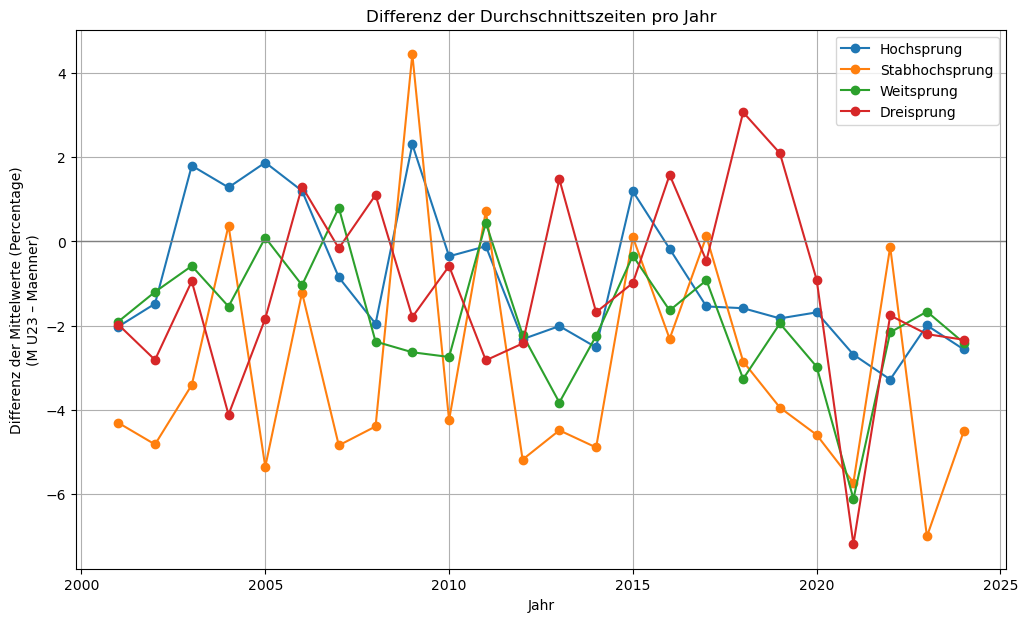

In [6]:
plt.figure(figsize=(12, 7))

# Seconds does not allow for comparison between distances, its clear there is more difference in longer races7
# Changing to percentage difference

run_disciplines = ['1500 m', '5000 m']
sprint_disciplines = ['100 m', '200 m', '400 m']  # example, adjust # ascending true
throw_disciplines = ['Kugelstoss', 'Diskuswurf', 'Hammerwurf', 'Speerwurf']
jump_disciplines = ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']

for disziplin in jump_disciplines:
    # Mittelwerte speichern
    means = {}

    for altersklasse in ["U23", "Maenner"]:
        subset = df[
            (df["disziplin"] == disziplin) &
            (df["geschlecht"] == "M") &
            (df["altersklasse"] == altersklasse)
        ].copy()
        # Mittelwert pro Jahr
        subset = (
                subset.sort_values(["jahr"], ascending=False)
                       .groupby("jahr")
                       .head(30)
            )
        print(max(subset["leistung"]))
        means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
    # gemeinsame Jahre
    common_years = means["U23"].index.intersection(means["Maenner"].index)
    # einfache Differenz der Mittelwerte
    difference = (means["U23"].loc[common_years] - means["Maenner"].loc[common_years]) \
                / means["Maenner"].loc[common_years] * 100
    

    # Plotten
    plt.plot(
        difference.index,
        difference.values,
        marker="o",
        label=disziplin
    )

plt.axhline(0, color="gray", linewidth=1)  # Hilfslinie
plt.xlabel("Jahr")
plt.ylabel("Differenz der Mittelwerte (Percentage)\n(M U23 – Maenner)")
plt.title("Differenz der Durchschnittszeiten pro Jahr")
plt.legend()
plt.grid(True)
plt.show()


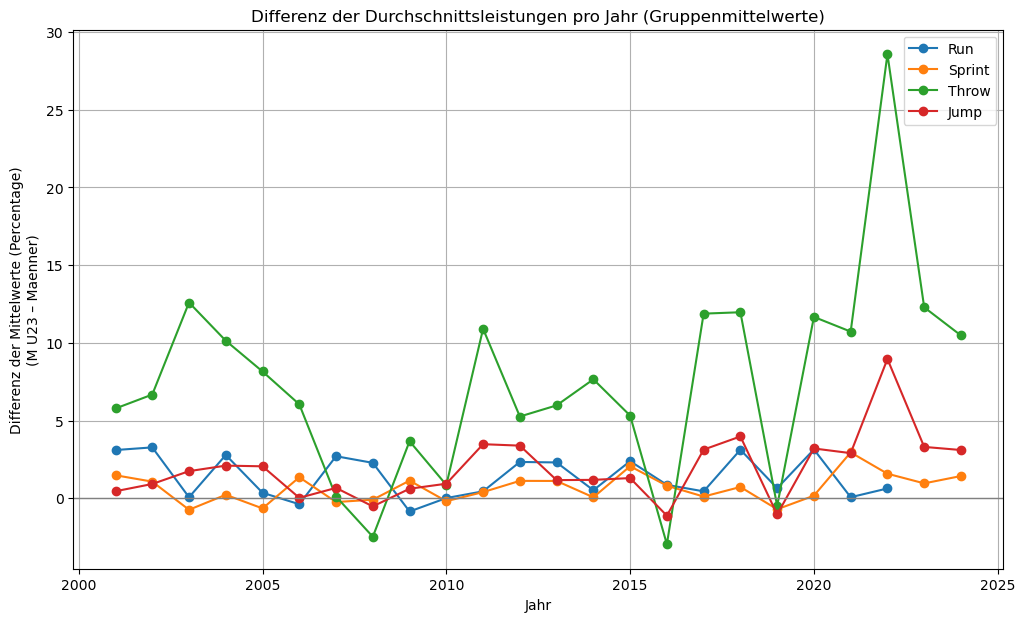

In [7]:
plt.figure(figsize=(12, 7))

# Discipline groups
run_disciplines = ['800m', '1500 m', '3000 m', '5000 m']
sprint_disciplines = ['100 m', '200 m', '400 m']
throw_disciplines = ['Kugelstoss', 'Diskuswurf', 'Hammerwurf', 'Speerwurf']
jump_disciplines = ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']

groups = {
    "Run": run_disciplines,
    "Sprint": sprint_disciplines,
    "Throw": throw_disciplines,
    "Jump": jump_disciplines
}

group_differences = {}

for group_name, disciplines in groups.items():
    diffs_list = []

    for disziplin in disciplines:
        means = {}

        for altersklasse in ["U23", "Maenner"]:
            subset = df[
                (df["disziplin"] == disziplin) &
                (df["geschlecht"] == "M") &
                (df["altersklasse"] == altersklasse)
            ].copy()

            if subset.empty:
                means[altersklasse] = pd.Series(dtype=float)
            else:
                if group_name in ["Throw", "Jump"]:
                    subset = (
                        subset.sort_values("jahr", ascending=True)
                              .groupby("jahr")
                              .head(25)
                    )
                else:
                    subset = (
                        subset.sort_values("jahr", ascending=False)
                              .groupby("jahr")
                              .head(25)
                    )

                means[altersklasse] = subset.groupby("jahr")["leistung"].mean()

        # Skip discipline if either group has no data
        if means["U23"].empty or means["Maenner"].empty:
            continue

        # Only common years
        common_years = means["U23"].index.intersection(means["Maenner"].index)
        if len(common_years) == 0:
            continue

        # Percentage difference
        difference = (means["U23"].loc[common_years] - means["Maenner"].loc[common_years]) \
                     / means["Maenner"].loc[common_years] * 100

        # Negate for Throws/Jumps if desired
        if group_name in ["Throw", "Jump"]:
            difference = -difference

        diffs_list.append(difference)

    if diffs_list:
        # Average across all disciplines in the group
        group_diff = pd.concat(diffs_list, axis=1).mean(axis=1)
        group_differences[group_name] = group_diff
        plt.plot(group_diff.index, group_diff.values, marker="o", label=group_name)

# Formatting
plt.axhline(0, color="gray", linewidth=1)
plt.xlabel("Jahr")
plt.ylabel("Differenz der Mittelwerte (Percentage)\n(M U23 – Maenner)")
plt.title("Differenz der Durchschnittsleistungen pro Jahr (Gruppenmittelwerte)")
plt.legend()
plt.grid(True)
plt.show()


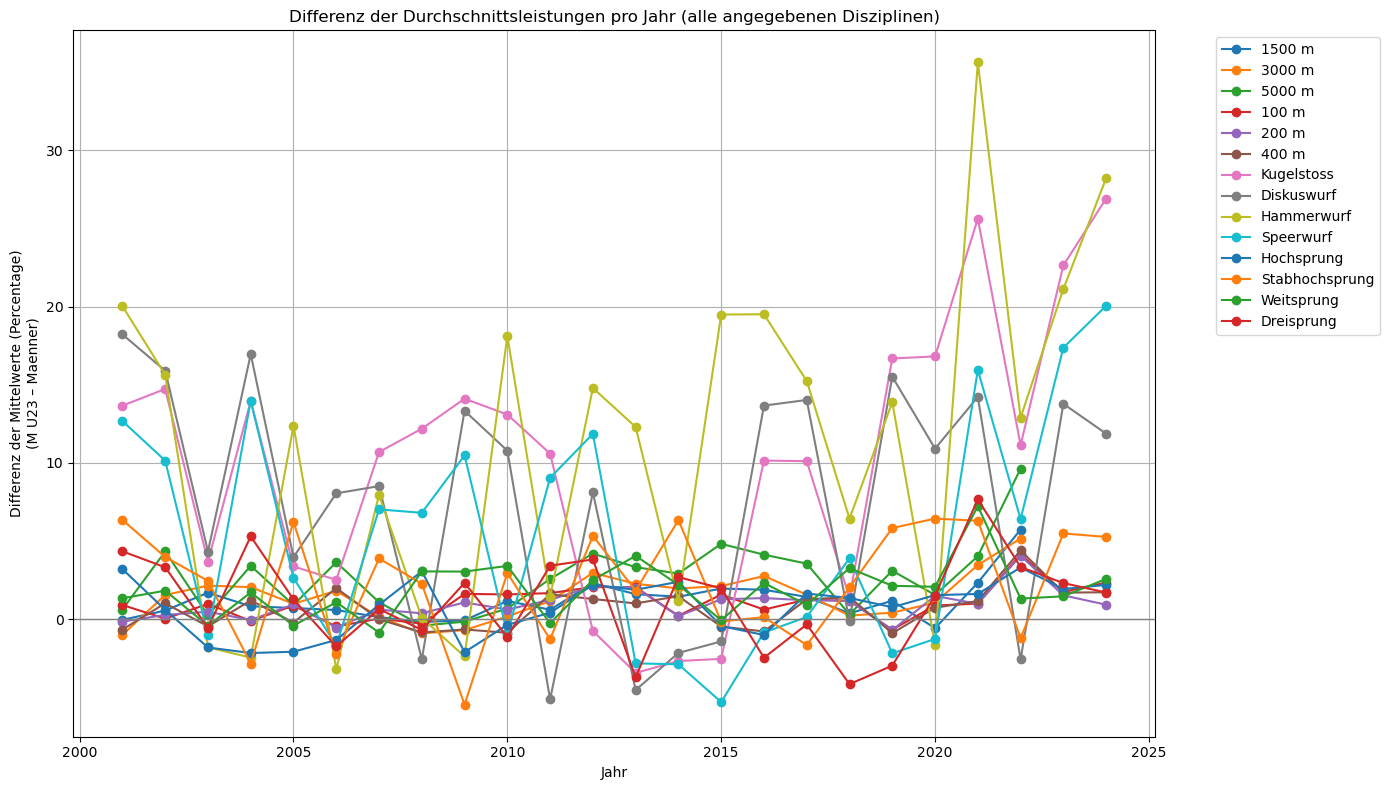

In [8]:
plt.figure(figsize=(14, 8))

# All stated disciplines
all_disciplines = run_disciplines + sprint_disciplines + throw_disciplines + jump_disciplines

for disziplin in all_disciplines:
    means = {}
    
    for altersklasse in ["U23", "Maenner"]:
        subset = df[
            (df["disziplin"] == disziplin) &
            (df["geschlecht"] == "M") &
            (df["altersklasse"] == altersklasse)
        ].copy()
        
        if subset.empty:
            means[altersklasse] = pd.Series(dtype=float)
        else:
            # Use different sorting depending on discipline type
            if disziplin in throw_disciplines + jump_disciplines:
                # For Throws and Jumps: ascending = True
                subset = (
                    subset.sort_values("jahr", ascending=False)
                          .groupby("jahr")
                          .head(25)
                )
            else:
                # For Runs & Sprints: ascending = False
                subset = (
                    subset.sort_values("jahr", ascending=True)
                          .groupby("jahr")
                          .head(25)
                )

            # Compute mean per year
            means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
    
    # Skip if either group has no data
    if means["U23"].empty or means["Maenner"].empty:
        continue
    
    # Only common years
    common_years = means["U23"].index.intersection(means["Maenner"].index)
    if len(common_years) == 0:
        continue
    
    # Percentage difference
    difference = (means["U23"].loc[common_years] - means["Maenner"].loc[common_years]) \
                 / means["Maenner"].loc[common_years] * 100
    
    # Negate for Throws/Jumps to keep interpretation consistent
    if disziplin in throw_disciplines + jump_disciplines:
        difference = -difference
    
    # Plot the discipline
    plt.plot(difference.index, difference.values, marker="o", label=disziplin)

# Formatting
plt.axhline(0, color="gray", linewidth=1)
plt.xlabel("Jahr")
plt.ylabel("Differenz der Mittelwerte (Percentage)\n(M U23 – Maenner)")
plt.title("Differenz der Durchschnittsleistungen pro Jahr (alle angegebenen Disziplinen)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend outside
plt.grid(True)
plt.tight_layout()
plt.show()


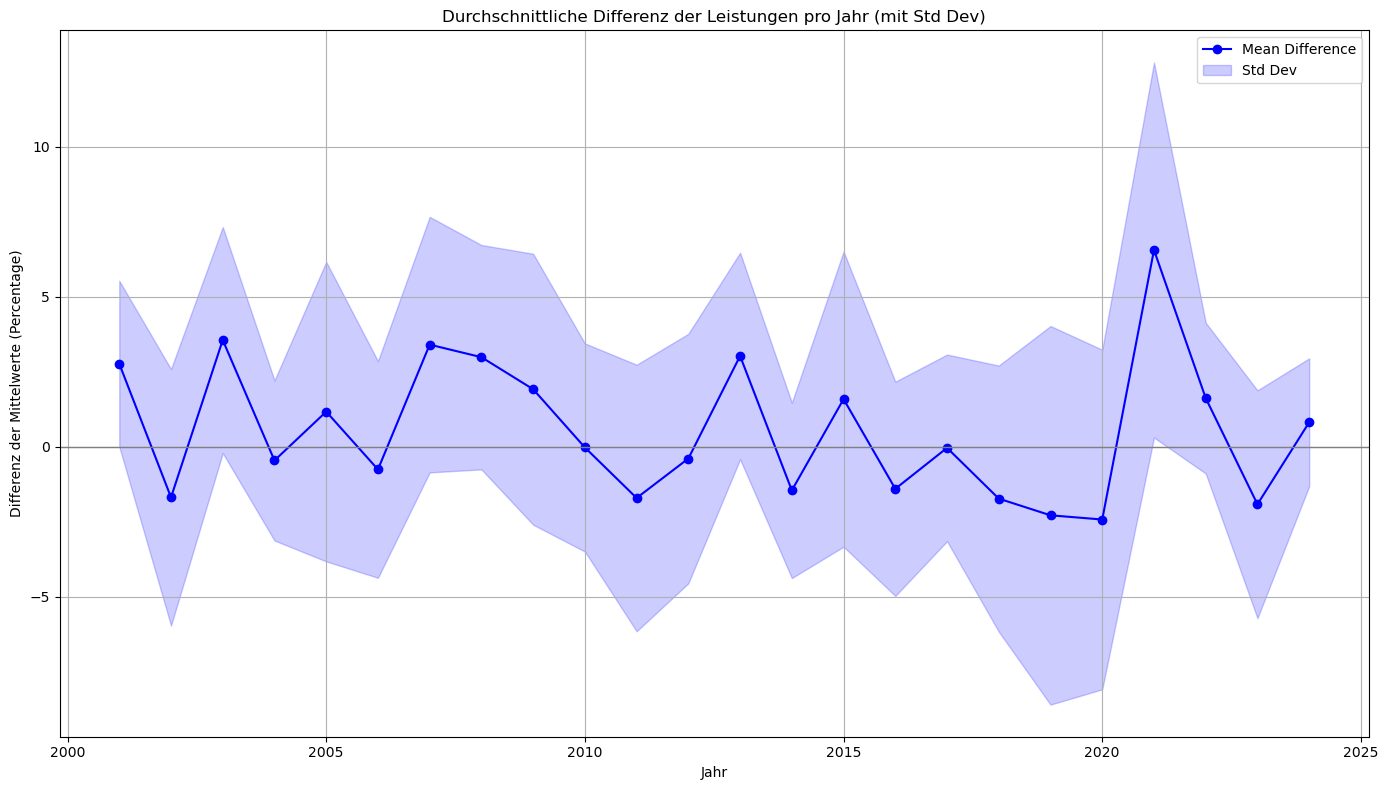

In [9]:
plt.figure(figsize=(14, 8))

all_disciplines = run_disciplines + sprint_disciplines + throw_disciplines + jump_disciplines
diffs_list = []

altersklasse1 = "U23"
altersklasse2 = "Frauen"
gender = "W"

for disziplin in all_disciplines:
    means = {}
    
    for altersklasse in [altersklasse1, altersklasse2]:
        subset = df[
            (df["disziplin"] == disziplin) &
            (df["geschlecht"] == gender) &
            (df["altersklasse"] == altersklasse)
        ].copy()
        
        if subset.empty:
            means[altersklasse] = pd.Series(dtype=float)
        else:
            if disziplin in throw_disciplines + jump_disciplines:
                subset = (
                    subset.sort_values("jahr", ascending=False)
                          .groupby("jahr")
                          .head(25)
                )
            else:
                subset = (
                    subset.sort_values("jahr", ascending=True)
                          .groupby("jahr")
                          .head(25)
                )
            means[altersklasse] = pd.to_numeric(subset.groupby("jahr")["leistung"].mean(), errors='coerce')
    
    # Skip if either group has no numeric data
    if means[altersklasse1].empty or means[altersklasse2].empty:
        continue
    
    common_years = means[altersklasse1].index.intersection(means[altersklasse2].index)
    if len(common_years) == 0:
        continue
    
    difference = (means[altersklasse1].loc[common_years] - means[altersklasse2].loc[common_years]) \
                 / means[altersklasse2].loc[common_years] * 100
    
    if disziplin in throw_disciplines + jump_disciplines:
        difference = -difference
    
    # Drop NaNs and force numeric type
    difference = pd.to_numeric(difference, errors='coerce').dropna()
    
    if not difference.empty:
        diffs_list.append(difference)

# Combine all differences safely
if diffs_list:
    df_diffs = pd.concat(diffs_list, axis=1)
    df_diffs = df_diffs.apply(pd.to_numeric, errors='coerce')
    df_diffs = df_diffs.dropna(how='all')  # drop rows where all disciplines are NaN

    mean_diff = df_diffs.mean(axis=1)
    std_diff = df_diffs.std(axis=1)
    
    plt.plot(mean_diff.index, mean_diff.values, marker="o", color="blue", label="Mean Difference")
    plt.fill_between(mean_diff.index, mean_diff - std_diff, mean_diff + std_diff,
                     color="blue", alpha=0.2, label="Std Dev")

plt.axhline(0, color="gray", linewidth=1)
plt.xlabel("Jahr")
plt.ylabel("Differenz der Mittelwerte (Percentage)")
plt.title("Durchschnittliche Differenz der Leistungen pro Jahr (mit Std Dev)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


jahr
2001   -3.215554
2002   -0.611855
2003    1.797928
2004    2.151379
2005    2.070433
2006    1.315789
2007   -0.931736
2008   -3.067485
2009    2.093114
2010    0.347826
2011   -0.426109
2012   -2.201317
2013   -1.892094
2014    -2.40105
2015    0.425614
2016    1.000962
2017   -1.649602
2018   -1.367262
2019   -0.777001
2020   -1.547389
2021   -1.624084
2022   -3.318541
2023   -1.943288
2024   -2.203526
Name: leistung, dtype: object


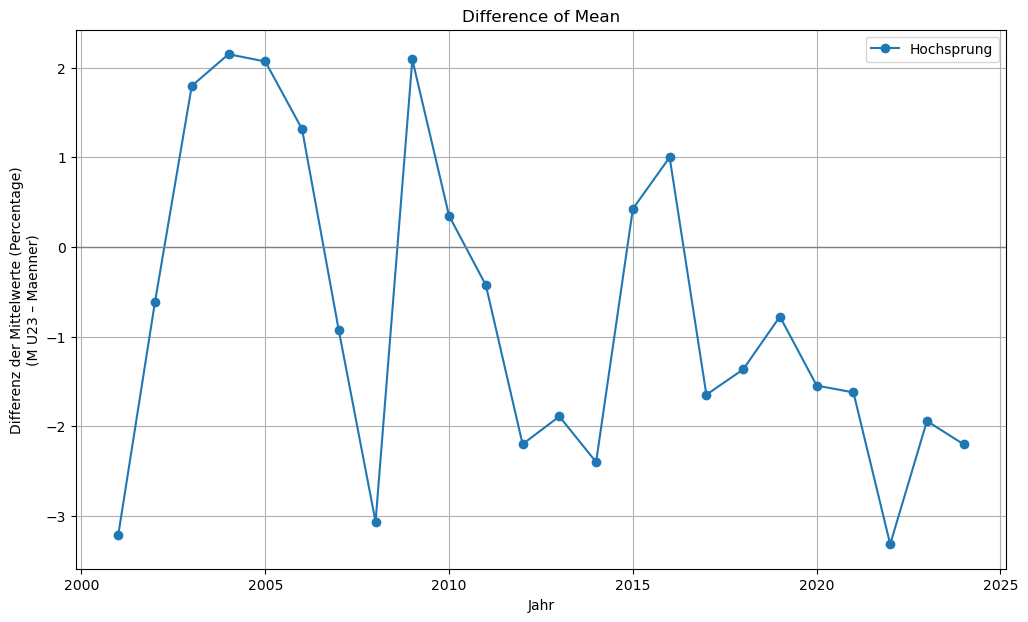

In [10]:
plt.figure(figsize=(12, 7))

# Seconds does not allow for comparison between distances, its clear there is more difference in longer races7
# Changing to percentage difference

disziplinen = ["Hochsprung"]

for disziplin in disziplinen:
    # Mittelwerte speichern
    means = {}

    for altersklasse in ["U23", "Maenner"]:
        subset = df[
            (df["disziplin"] == disziplin) &
            (df["geschlecht"] == "M") &
            (df["altersklasse"] == altersklasse)
        ].copy()
        # Mittelwert pro Jahr
        subset = (
                subset.sort_values(["jahr"], ascending=False)
                       .groupby("jahr")
                       .head(25)
            )
        means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
        
    # gemeinsame Jahre
    common_years = means["U23"].index.intersection(means["Maenner"].index)
    # einfache Differenz der Mittelwerte
    difference = (means["U23"].loc[common_years] - means["Maenner"].loc[common_years]) \
                / means["Maenner"].loc[common_years] * 100
    print(difference)
    # Plotten
    plt.plot(
        difference.index,
        difference.values,
        marker="o",
        label=disziplin
    )

plt.axhline(0, color="gray", linewidth=1)  # Hilfslinie
plt.xlabel("Jahr")
plt.ylabel("Differenz der Mittelwerte (Percentage)\n(M U23 – Maenner)")
plt.title("Difference of Mean")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
# Mean Difference for M U23 and Maenner and W U23 and Frauen summed over all years for every disziplin
disziplinen = ["800 m","1500 m", "3000 m", "5000 m", "10 km"]
gender = ["W", "M"]
for gender in gender:
    if gender == "W":
        ak = "Frauen"
    else:
        ak = "Maenner"
    print(ak)
    for disziplin in disziplinen:
        # Mittelwerte speichern
        means = {}
        for altersklasse in ["U23", ak]:
            subset = df[
                (df["disziplin"] == disziplin) &
                (df["geschlecht"] == gender) &
                (df["altersklasse"] == altersklasse)
            ].copy()
            means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
        # gemeinsame Jahre
        common_years = means["U23"].index.intersection(means[ak].index)
        common_years = common_years[common_years != 2020]
        # einfache Differenz der Mittelwerte
        difference = (means["U23"].loc[common_years] - means[ak].loc[common_years]) \
                    / means[ak].loc[common_years] * 100
        avg_difference = difference.mean()
        print(f"Average difference in {disziplin} for {gender} and U23: {avg_difference:.2f}%")


Frauen
Average difference in 800 m for W and U23: 2.46%
Average difference in 1500 m for W and U23: 0.85%
Average difference in 3000 m for W and U23: 1.22%
Average difference in 5000 m for W and U23: 2.54%
Average difference in 10 km for W and U23: 4.37%
Maenner
Average difference in 800 m for M and U23: 0.53%
Average difference in 1500 m for M and U23: 1.09%
Average difference in 3000 m for M and U23: 1.43%
Average difference in 5000 m for M and U23: 2.31%
Average difference in 10 km for M and U23: 3.02%


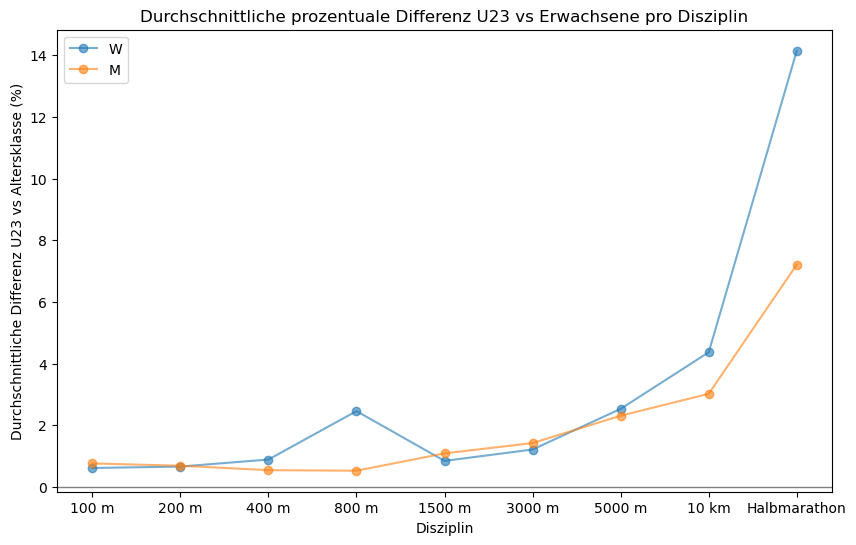

In [ ]:
import lib.plotting_style as plt

disziplinen = ["100 m","200 m","400 m","800 m","1500 m", "3000 m", "5000 m", "10 km", "Halbmarathon"]
genders = ["W", "M"]

# Ergebnisse speichern
results = {"Disziplin": [], "Gender": [], "AvgDiffPercent": []}

for gender in genders:
    ak = "Frauen" if gender == "W" else "Maenner"
    
    for disziplin in disziplinen:
        means = {}
        for altersklasse in ["U23", ak]:
            subset = df[
                (df["disziplin"] == disziplin) &
                (df["geschlecht"] == gender) &
                (df["altersklasse"] == altersklasse)
            ].copy()
            means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
        
        # Gemeinsame Jahre, 2020 ausschließen
        common_years = means["U23"].index.intersection(means[ak].index)
        common_years = common_years[common_years != 2020]
        
        # Prozentdifferenz berechnen
        difference = (means["U23"].loc[common_years] - means[ak].loc[common_years]) \
                     / means[ak].loc[common_years] * 100
        avg_difference = difference.mean()
        
        # Ergebnisse speichern
        results["Disziplin"].append(disziplin)
        results["Gender"].append(gender)
        results["AvgDiffPercent"].append(avg_difference)

# Plot
fig, ax = plt.subplots(figsize=(10,6))

for gender in genders:
    mask = [g == gender for g in results["Gender"]]
    x = [d for d, m in zip(results["Disziplin"], mask) if m]
    y = [v for v, m in zip(results["AvgDiffPercent"], mask) if m]
    ax.plot(x, y, marker="o", alpha=0.6, label=gender)

ax.set_xlabel("Disziplin")
ax.set_ylabel("Durchschnittliche Differenz U23 vs Altersklasse (%)")
ax.set_title("Durchschnittliche prozentuale Differenz U23 vs Erwachsene pro Disziplin")
ax.axhline(0, color="gray", linewidth=1)
ax.legend(["W", "M"])
plt.show()


In [ ]:
import lib.plotting_style as plt
import pandas as pd

data_wa = pd.read_csv("C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\data_with_wa_scores.csv", sep=",")
#Drop al None entries in wa_score
data_wa = data_wa.dropna(subset=["wa_score"])

#get all data where wa score less than 50
data_wa_filtered = data_wa[data_wa["wa_score"] < 20]

#filter for only olympic distances
olympic_distances = olympic_disciplines = [
    # Lauf
    '100 m', '200 m', '400 m', '800 m', '1500 m', '5000 m', '10000 m', 'Marathon',
    '100 m Huerden', '110 m Hürden', '400 m Huerden', '3000 m Hindernis', 
    '20 km Gehen', '50 km Gehen',

    # Sprung/Wurf
    'Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung',
    'Kugelstoß', 'Diskuswurf', 'Hammerwurf', 'Speerwurf',

    # Mehrkampf
    'Siebenkampf', 'Zehnkampf'
]

data_wa["altersklasse"] = data_wa["altersklasse"].replace({"Maenner": "Erwachsene", "Frauen": "Erwachsene"})

data_wa = data_wa[(data_wa["disziplin"].isin(olympic_distances)) &
                           (data_wa["altersklasse"] == "Erwachsene")]

data_wa = data_wa[(data_wa["wa_score"] > 25) & (data_wa["wa_score"] < 1380)]

# AK Maenner and Women to adult
data_wa.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,wa_score
0,2017,W,Erwachsene,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211.0
1,2017,W,Erwachsene,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187.0
2,2017,W,Erwachsene,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169.0
3,2017,W,Erwachsene,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148.0
4,2017,W,Erwachsene,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146.0


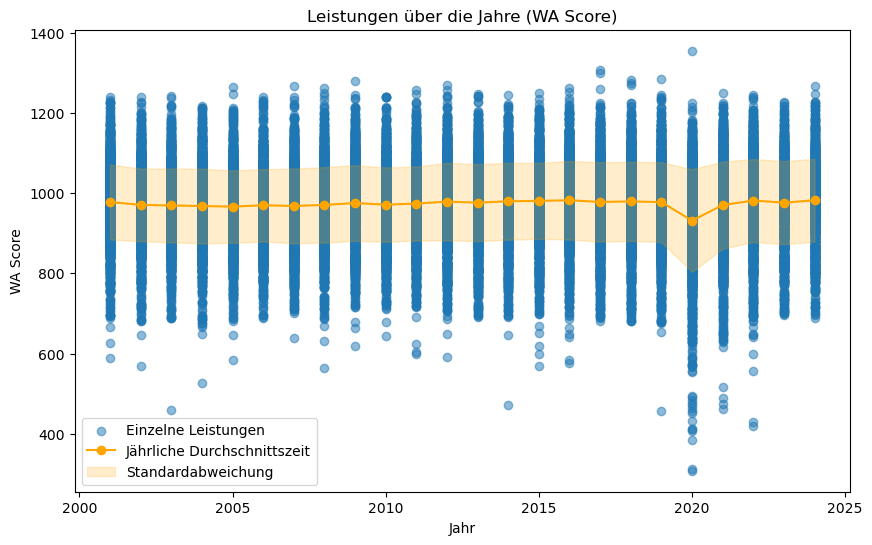

In [14]:

# Plot all data points with times on y-axis and year on x-axis + Mean per year line
mean_per_year = data_wa.groupby("jahr")["wa_score"].mean()
#Plot also stadard deviation as shaded area
std_per_year = data_wa.groupby("jahr")["wa_score"].std()
plt.figure(figsize=(10, 6))
plt.scatter(data_wa["jahr"], data_wa["wa_score"], alpha=0.5, label="Einzelne Leistungen")
plt.plot(mean_per_year.index, mean_per_year.values, color='orange', marker='o', label='Jährliche Durchschnittszeit')
plt.fill_between(
    mean_per_year.index,
    mean_per_year - std_per_year,
    mean_per_year + std_per_year,
    color='orange',
    alpha=0.2,
    label='Standardabweichung'
)
plt.title(f'Leistungen über die Jahre (WA Score)')
plt.xlabel('Jahr')              
plt.ylabel('WA Score')
plt.legend()
plt.show()